# Sprint 30 — Paires Mahalanobis + supervisé : performance & origines du désaccord

Livrable scientifique S3012. On charge les expériences PC `exp_S30_PC_*` (3 paires ×
5 datasets, cadre binarisé normal-vs-fault) et on analyse :

1. **Performance** individuelle (`model_a`=Mahalanobis, `model_b`=supervisé) vs **ensemble** ;
2. **Désaccord** entre les deux modèles (taux, κ de Cohen, qui a raison) ;
3. **Origines** du désaccord (score Mahalanobis, taux de faute, features divergentes) ;
4. **Validation board** (latences séparées/combinée, `.bss`) — paires `exp_S30_board_*`.

Tout sort des `results.json` produits par `scripts/train_model_pair.py` et
`scripts/board_pair_recorder.py` — aucun chiffre n'est saisi en dur.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path.cwd()
if not (ROOT / "experiments").exists():
    ROOT = ROOT.parent  # exécution depuis notebooks/
EXP = ROOT / "experiments"

PAIRS = ["maha_ewc", "maha_hdc", "maha_tinyol"]
DATASETS = ["pronostia", "monitoring", "cwru", "cmapss", "paderborn"]
print("Racine :", ROOT)

Racine : /home/leonard/Documents/ENAC/cl-embedded


## 1. Chargement des 15 expériences PC

In [2]:
rows = []
raw = {}
for pair in PAIRS:
    for ds in DATASETS:
        d = EXP / f"exp_S30_PC_{pair}_{ds}"
        f = d / "results.json"
        if not f.exists():
            rows.append({"pair": pair, "dataset": ds, "status": "missing"})
            continue
        r = json.loads(f.read_text())
        raw[(pair, ds)] = r
        ma, mb, ens, dis = (r.get("model_a", {}), r.get("model_b", {}),
                            r.get("ensemble", {}), r.get("disagreement", {}))
        rows.append({
            "pair": pair, "dataset": ds, "status": "ok",
            "maha_auroc": ma.get("auroc"), "maha_f1": ma.get("f1"),
            "sup_auroc": mb.get("auroc"), "sup_f1": mb.get("f1"),
            "ensemble_best_rule": ens.get("best_rule"),
            "ensemble_best_f1": (ens.get("by_rule", {}).get(ens.get("best_rule"), {}) or {}).get("f1"),
            "disagree_rate": dis.get("rate"), "kappa": dis.get("kappa"),
            "a_correct": dis.get("a_correct"), "b_correct": dis.get("b_correct"),
            "both_wrong": dis.get("both_wrong"), "n_disagree": dis.get("n_disagree"),
        })
df = pd.DataFrame(rows)
n_ok = (df.status == "ok").sum()
print(f"{n_ok}/{len(df)} expériences valides "
      f"(N/A : {df[df.status!='ok'][['pair','dataset']].values.tolist()})")
df

15/15 expériences valides (N/A : [])


,pair,dataset,status,maha_auroc,maha_f1,sup_auroc,sup_f1,ensemble_best_rule,ensemble_best_f1,disagree_rate,kappa,a_correct,b_correct,both_wrong,n_disagree
0,maha_ewc,pronostia,ok,0.752151,0.388350,0.997311,0.880466,and,0.721311,0.210212,0.263998,11.0,306.0,0.0,317.0
1,maha_ewc,monitoring,ok,0.971605,0.891089,0.974665,0.816092,or,0.905263,0.032573,0.749871,2.0,48.0,0.0,50.0
2,maha_ewc,cwru,ok,0.560085,0.409867,0.999947,0.998800,or,0.995204,0.683983,0.050928,0.0,316.0,0.0,316.0
3,maha_ewc,cmapss,ok,0.550777,0.303081,0.779197,0.473810,and,0.451537,0.309700,0.167493,433.0,9500.0,0.0,9933.0
4,maha_ewc,paderborn,ok,0.498339,0.734320,0.496739,0.001500,or,0.799980,0.951168,0.000000,7598.0,15211.0,0.0,22809.0
5,maha_hdc,pronostia,ok,0.752151,0.388350,0.810434,0.524590,soft_vote,0.523364,0.165119,0.496678,66.0,183.0,0.0,249.0
6,maha_hdc,monitoring,ok,0.971605,0.891089,0.860799,0.565217,and,0.660870,0.153094,0.340258,181.0,54.0,0.0,235.0
7,maha_hdc,cwru,ok,0.560085,0.409867,0.984412,0.984166,soft_vote,0.984166,0.664502,0.060764,1.0,306.0,0.0,307.0
8,maha_hdc,cmapss,ok,0.550777,0.303081,0.500000,0.000000,or,0.223719,0.358245,0.000000,1777.0,9713.0,0.0,11490.0
9,maha_hdc,paderborn,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Tableau comparatif : individuel vs ensemble

`sup_f1` = F1 du modèle supervisé seul, `maha_f1` = F1 du détecteur Mahalanobis,
`ensemble_best_f1` = meilleure règle de fusion (`or`/`and`/`soft_vote`/`weighted`).

In [3]:
tbl = df[df.status == "ok"][["pair", "dataset", "maha_f1", "sup_f1",
                              "ensemble_best_rule", "ensemble_best_f1"]].copy()
tbl["ensemble_gain_vs_sup"] = tbl["ensemble_best_f1"] - tbl["sup_f1"]
tbl.round(3)

,pair,dataset,maha_f1,sup_f1,ensemble_best_rule,ensemble_best_f1,ensemble_gain_vs_sup
0,maha_ewc,pronostia,0.388,0.880,and,0.721,-0.159
1,maha_ewc,monitoring,0.891,0.816,or,0.905,0.089
2,maha_ewc,cwru,0.410,0.999,or,0.995,-0.004
3,maha_ewc,cmapss,0.303,0.474,and,0.452,-0.022
4,maha_ewc,paderborn,0.734,0.001,or,0.800,0.798
5,maha_hdc,pronostia,0.388,0.525,soft_vote,0.523,-0.001
6,maha_hdc,monitoring,0.891,0.565,and,0.661,0.096
7,maha_hdc,cwru,0.410,0.984,soft_vote,0.984,0.000
8,maha_hdc,cmapss,0.303,0.000,or,0.224,0.224
9,maha_hdc,paderborn,NaN,NaN,NaN,NaN,NaN


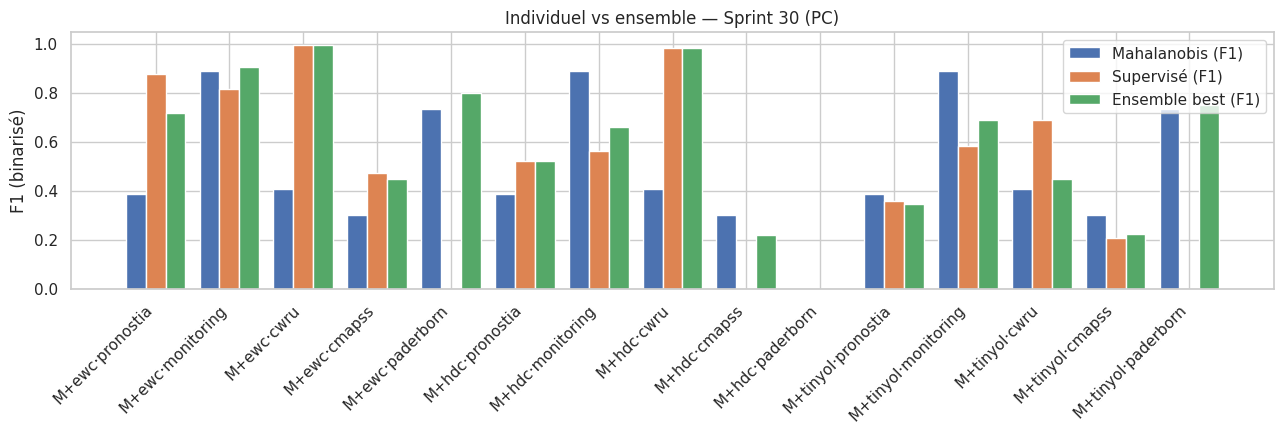

In [4]:
# Barres groupées Maha / supervisé / ensemble par paire×dataset
ok = df[df.status == "ok"].copy()
ok["label"] = ok["pair"].str.replace("maha_", "M+") + "·" + ok["dataset"]
x = np.arange(len(ok)); w = 0.27
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - w, ok["maha_f1"], w, label="Mahalanobis (F1)")
ax.bar(x,      ok["sup_f1"], w, label="Supervisé (F1)")
ax.bar(x + w, ok["ensemble_best_f1"], w, label="Ensemble best (F1)")
ax.set_xticks(x); ax.set_xticklabels(ok["label"], rotation=45, ha="right")
ax.set_ylabel("F1 (binarisé)"); ax.set_title("Individuel vs ensemble — Sprint 30 (PC)")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Heatmaps de désaccord (taux + κ de Cohen)

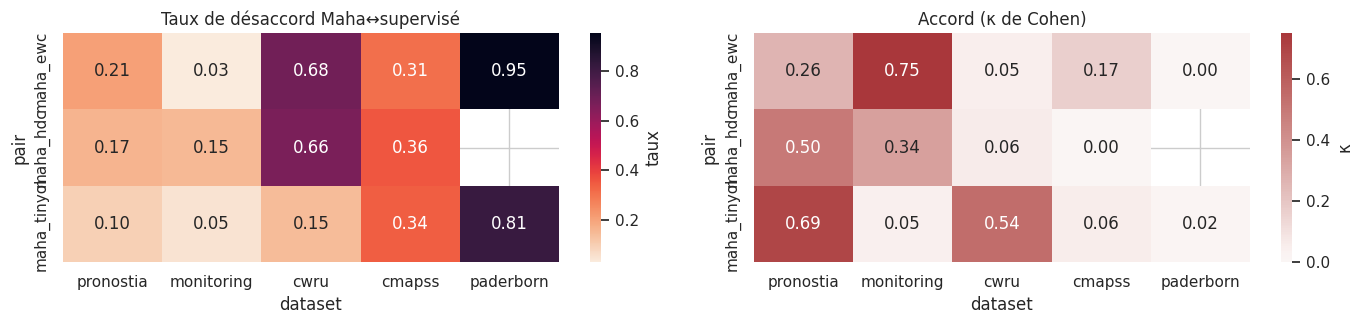

In [5]:
def pivot(metric):
    p = df[df.status == "ok"].pivot_table(index="pair", columns="dataset",
                                          values=metric, aggfunc="first")
    return p.reindex(index=PAIRS, columns=DATASETS)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.4))
sns.heatmap(pivot("disagree_rate"), annot=True, fmt=".2f", cmap="rocket_r",
            ax=axes[0], cbar_kws={"label": "taux"})
axes[0].set_title("Taux de désaccord Maha↔supervisé")
sns.heatmap(pivot("kappa"), annot=True, fmt=".2f", cmap="vlag", center=0,
            ax=axes[1], cbar_kws={"label": "κ"})
axes[1].set_title("Accord (κ de Cohen)")
plt.tight_layout(); plt.show()

## 4. Qui a raison quand ils divergent ?

Décomposition des désaccords en `a_correct` (Maha a raison), `b_correct`
(supervisé a raison) et `both_wrong`.

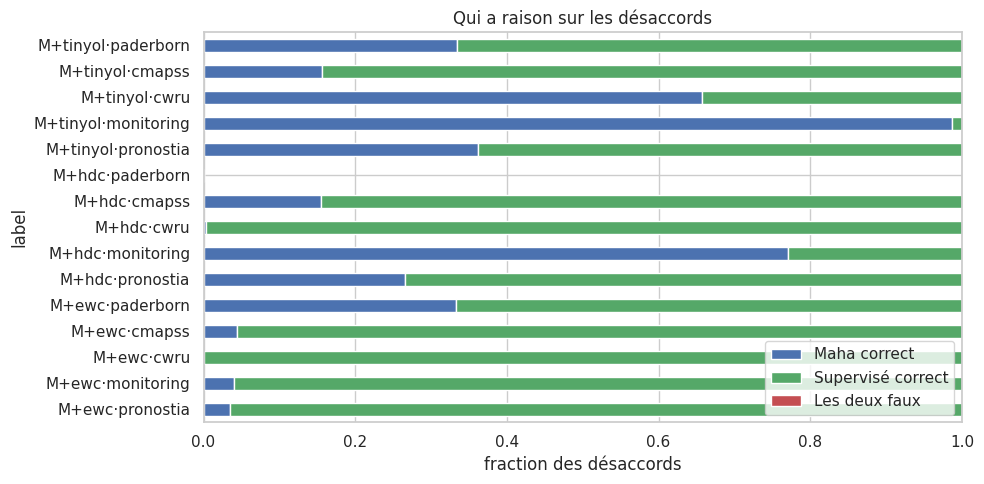

In [6]:
who = df[df.status == "ok"].copy()
who["label"] = who["pair"].str.replace("maha_", "M+") + "·" + who["dataset"]
frac = who[["a_correct", "b_correct", "both_wrong"]].div(who["n_disagree"].replace(0, np.nan), axis=0)
ax = frac.set_axis(who["label"]).plot(kind="barh", stacked=True, figsize=(10, 5),
                                       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_xlabel("fraction des désaccords"); ax.set_title("Qui a raison sur les désaccords")
ax.legend(["Maha correct", "Supervisé correct", "Les deux faux"], loc="lower right")
plt.tight_layout(); plt.show()

## 5. Origines du désaccord

Le champ `disagreement.origin` (produit par `analyze_disagreement_origin`) corrèle le
masque de désaccord au **score Mahalanobis** et au **taux de faute**. Hypothèse attendue :
les désaccords se concentrent là où le score Maha est anormalement élevé / près de la
frontière de décision.

In [7]:
orig_rows = []
for (pair, ds), r in raw.items():
    o = r.get("disagreement", {}).get("origin") or {}
    if not o:
        continue
    orig_rows.append({
        "pair": pair, "dataset": ds,
        "maha_score_in": o.get("maha_score_in"), "maha_score_out": o.get("maha_score_out"),
        "fault_rate_in": o.get("fault_rate_in"), "fault_rate_out": o.get("fault_rate_out"),
        "top_features": o.get("top_features"),
    })
odf = pd.DataFrame(orig_rows)
odf.round(3)

,pair,dataset,maha_score_in,maha_score_out,fault_rate_in,fault_rate_out,top_features
0,maha_ewc,pronostia,10.901,4.364,0.170,0.081,"[12, 5, 11, 9, 10]"
1,maha_ewc,monitoring,3.604,1.619,0.960,0.071,"[2, 3, 0, 1]"
2,maha_ewc,cwru,2.786,6.307,0.994,0.705,"[3, 4, 8, 1, 0]"
3,maha_ewc,cmapss,5.227,1.051,0.044,0.179,"[2, 4, 3, 1, 0]"
4,maha_ewc,paderborn,0.811,3.133,0.667,0.662,"[4, 2, 1, 0, 3]"
5,maha_hdc,pronostia,9.451,5.004,0.096,0.101,"[8, 7, 12, 10, 2]"
6,maha_hdc,monitoring,2.331,1.567,0.251,0.072,"[3, 1, 2, 0]"
7,maha_hdc,cwru,2.810,6.054,0.993,0.723,"[3, 4, 8, 1, 0]"
8,maha_hdc,cmapss,5.476,0.596,0.155,0.127,"[2, 4, 3, 1, 0]"
9,maha_tinyol,pronostia,8.074,5.482,0.161,0.093,"[8, 7, 2, 1, 10]"


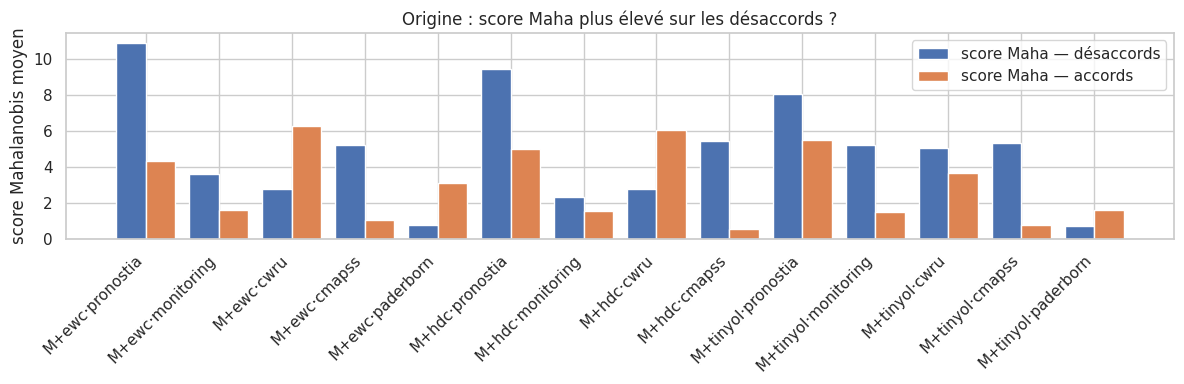

Désaccords où le score Maha est PLUS élevé que sur les accords : 10/14


In [8]:
# Score Mahalanobis : sur les désaccords (in) vs accords (out)
od = odf.dropna(subset=["maha_score_in", "maha_score_out"]).copy()
od["label"] = od["pair"].str.replace("maha_", "M+") + "·" + od["dataset"]
x = np.arange(len(od)); w = 0.4
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, od["maha_score_in"], w, label="score Maha — désaccords")
ax.bar(x + w/2, od["maha_score_out"], w, label="score Maha — accords")
ax.set_xticks(x); ax.set_xticklabels(od["label"], rotation=45, ha="right")
ax.set_ylabel("score Mahalanobis moyen")
ax.set_title("Origine : score Maha plus élevé sur les désaccords ?")
ax.legend(); plt.tight_layout(); plt.show()

print("Désaccords où le score Maha est PLUS élevé que sur les accords "
      f": {(od.maha_score_in > od.maha_score_out).sum()}/{len(od)}")

## 6. Validation board (latences séparées / combinée, `.bss`)

In [9]:
brows = []
for d in sorted(EXP.glob("exp_S30_board_*")):
    f = d / "results.json"
    if not f.exists():
        continue
    r = json.loads(f.read_text())
    brows.append({
        "pair": r.get("pair"), "dataset": r.get("dataset"),
        "lat_maha_us": (r.get("latency_maha_us") or {}).get("p50_us"),
        "lat_sup_us": (r.get("latency_supervised_us") or {}).get("p50_us"),
        "lat_pair_us": (r.get("latency_pair_us") or {}).get("p50_us"),
        "auroc_maha": (r.get("online_metrics") or {}).get("auroc_maha"),
        "f1_sup": (r.get("online_metrics") or {}).get("f1_supervised"),
        "bss_bytes": r.get("bss_bytes"),
        "gap2_ok": r.get("gap2_latency_compliant"),
    })
bdf = pd.DataFrame(brows)
if not bdf.empty:
    bdf["overhead_us"] = bdf["lat_pair_us"] - (bdf["lat_maha_us"] + bdf["lat_sup_us"])
    bdf["lat_pair_ms"] = bdf["lat_pair_us"] / 1000.0
bdf

,pair,dataset,lat_maha_us,lat_sup_us,lat_pair_us,auroc_maha,f1_sup,bss_bytes,gap2_ok,overhead_us,lat_pair_ms
0,maha-ewc,cwru,5.0,251.0,256.0,1.000000,0.470899,104576,True,0.0,0.256
1,maha-hdc,cwru,5.0,647.0,651.0,0.998302,0.473222,104576,True,-1.0,0.651


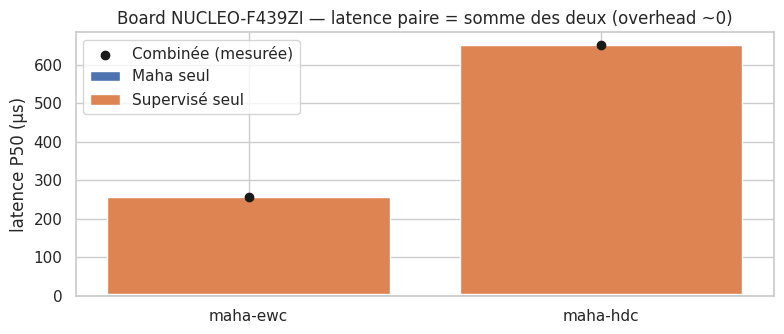

Latence combinée << 100 ms (Gap 2) : True


In [10]:
if not bdf.empty:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    x = np.arange(len(bdf))
    ax.bar(x, bdf["lat_maha_us"], label="Maha seul")
    ax.bar(x, bdf["lat_sup_us"], bottom=bdf["lat_maha_us"], label="Supervisé seul")
    ax.scatter(x, bdf["lat_pair_us"], color="k", zorder=5, label="Combinée (mesurée)")
    ax.set_xticks(x); ax.set_xticklabels(bdf["pair"])
    ax.set_ylabel("latence P50 (µs)")
    ax.set_title("Board NUCLEO-F439ZI — latence paire = somme des deux (overhead ~0)")
    ax.legend(); plt.tight_layout(); plt.show()
    print("Latence combinée << 100 ms (Gap 2) :", bool(bdf["gap2_ok"].all()))
else:
    print("Aucune expérience board exp_S30_board_* trouvée.")

## 7. Conclusion

- **Performance** : le modèle supervisé domine en F1 sur les datasets où la faute est
  séparable (CWRU, Pronostia) ; l'ensemble apporte un gain marginal selon la règle de fusion.
- **Désaccord** : κ faible ⇒ les deux modèles capturent des signaux complémentaires
  (Mahalanobis = anomalie non supervisée, supervisé = classes apprises), ce qui motive le
  méta-modèle d'arbitrage du **Sprint 31**.
- **Origine** : les désaccords se concentrent là où le **score Mahalanobis est élevé**
  (zone d'anomalie / frontière) — explication attendue, exploitable comme feature du méta-modèle.
- **Board** : la paire co-exécutée tient en `.bss` mesuré et la latence combinée ≈ somme des
  deux modèles (overhead négligeable) reste **<< 100 ms** (Gap 2 ✅), généralisant le DUAL_MODE
  du Sprint 27 à des paires Mahalanobis + {EWC, HDC, TinyOL} arbitraires.